In [19]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

LANDSCAPE_DIR = '../../examples/comparisons/free_boundary_DIIID/landscape/coils:3'
WEIGHTS = ['1e-04', '1e-03', '1e-02', '1e-01']
THETA1_ANCHOR = 20.0
ANGULAR_BOUNDS = (10, 170)
FAIL_MARKER = 1e6
RES = 512

def grid_shape(n):
    if n <= 1: return 1, 1
    if n == 2: return 1, 2
    if n <= 4: return 2, 2
    return (n + 2) // 3, 3

def fig_size(nr, nc, w_per=6.5, h_per=5.5):
    return (nc * w_per, nr * h_per)


In [20]:
def find_path(w_key):
    final = os.path.join(LANDSCAPE_DIR, f'weight:{w_key}.npz')
    ckpt = final + '.ckpt.npz'
    if os.path.exists(final):
        return final, 'final'
    if os.path.exists(ckpt):
        return ckpt, 'ckpt'
    return None, None

def load_w(w_key):
    p, kind = find_path(w_key)
    if p is None:
        return None
    d = dict(np.load(p, allow_pickle=False))
    d['_kind'] = kind
    d['_path'] = p
    return d

data = {w: load_w(w) for w in WEIGHTS}
data = {w: d for w, d in data.items() if d is not None}
missing = [w for w in WEIGHTS if w not in data]
if missing:
    print(f'missing: {missing}')
for w, d in data.items():
    cost = d['cost']
    n_total = cost.size
    n_done = int(np.isfinite(cost).sum())
    n_fail = int((cost >= FAIL_MARKER).sum())
    valid = np.isfinite(cost) & (cost < FAIL_MARKER)
    cmin = float(cost[valid].min()) if valid.any() else float('nan')
    cmax = float(cost[valid].max()) if valid.any() else float('nan')
    print(f'weight={w} kind={d["_kind"]} done={n_done}/{n_total} fails={n_fail} min={cmin:.4e} max={cmax:.4e}')

missing: ['1e-04', '1e-03', '1e-01']
weight=1e-02 kind=final done=65536/65536 fails=7963 min=1.2499e-03 max=3.2890e-02


In [21]:
def preprocess_cost(samples, cost):
    # TODO(human): return (samples_clean, cost_clean) ready for griddata.
    # Decide how to handle: NaN (pending), 1e6 (failed eval), outliers.
    valid = np.isfinite(cost) & (cost < FAIL_MARKER)

    return (samples[valid], cost[valid]) 

In [22]:
def grid_from_sobol(d, res=RES, method='linear'):
    s, c = preprocess_cost(d['samples'], d['cost'])
    th_lo, th_hi = ANGULAR_BOUNDS
    th2_lin = np.linspace(th_lo, th_hi, res)
    th3_lin = np.linspace(th_lo, th_hi, res)
    TH2, TH3 = np.meshgrid(th2_lin, th3_lin, indexing='ij')
    Z = griddata(s, c, (TH2, TH3), method=method)
    return th2_lin, th3_lin, Z

def dedup_topn(samples, costs, n=3, tol_deg=5.0, symmetric=True):
    order = np.argsort(costs)
    s_sorted = samples[order]
    c_sorted = costs[order]
    s_canon = np.sort(s_sorted, axis=1) if symmetric else s_sorted
    kept = [0]
    for i in range(1, len(s_canon)):
        if len(kept) >= n:
            break
        d = np.linalg.norm(s_canon[i] - s_canon[kept], axis=1)
        if d.min() > tol_deg:
            kept.append(i)
    return s_sorted[kept], c_sorted[kept]

def plot_heatmap(ax, d, w_key, log10=False, cmap='RdBu_r', method='linear', n_points=3, tol_deg=20):
    th2_lin, th3_lin, Z = grid_from_sobol(d, method=method)
    Zp = np.log10(Z) if log10 else Z
    extent = [th2_lin[0], th2_lin[-1], th3_lin[0], th3_lin[-1]]
    im = ax.imshow(Zp.T, origin='lower', extent=extent, aspect='auto', cmap=cmap)
    fail_mask = d['cost'] >= FAIL_MARKER
    fs = d['samples'][fail_mask]
    ax.scatter(fs[:, 0], fs[:, 1], s=8, color='green', alpha=0.6, zorder=2, label='fail (1e6)')
    ax.scatter(fs[:, 1], fs[:, 0], s=8, color='green', alpha=0.6, zorder=2)
    s, c = preprocess_cost(d['samples'], d['cost'])
    top_samples, top_costs = dedup_topn(s, c, n=n_points, tol_deg=tol_deg, symmetric=True)
    ax.scatter(top_samples[:, 0], top_samples[:, 1], marker='D', s=80, facecolor='lime', edgecolor='black', linewidth=1.0, zorder=5)
    ax.scatter(top_samples[:, 1], top_samples[:, 0], marker='D', s=80, facecolor='lime', edgecolor='black', linewidth=1.0, zorder=5)
    ax.set_xlabel(r'$\theta_2$ [deg]')
    ax.set_ylabel(r'$\theta_3$ [deg]')
    ax.set_title(
        rf'$w_{{fb}}$={w_key}, $\theta_1$={THETA1_ANCHOR:.0f}$^\circ$, kind={d["_kind"]}' + '\n' +
        rf'argmin: $\theta_2$={top_samples[0,0]:.1f}$^\circ$, $\theta_3$={top_samples[0,1]:.1f}$^\circ$, $\mathcal{{L}}$={top_costs[0]:.3e}',
        fontsize=10
    )
    return im

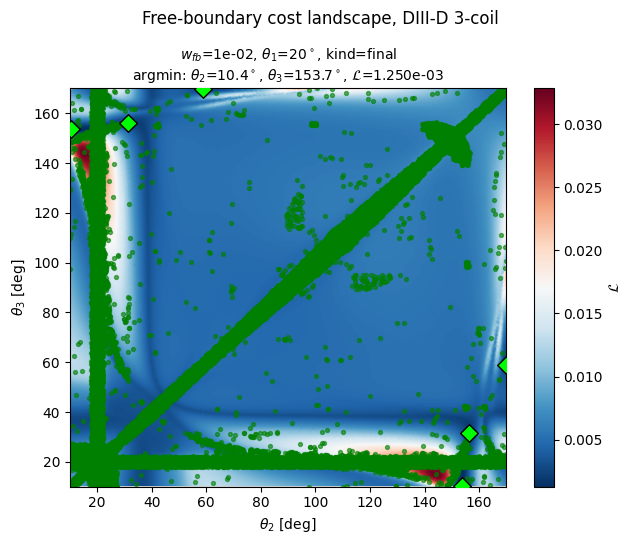

In [23]:
available = [w for w in WEIGHTS if w in data]
nr, nc = grid_shape(len(available))
fig, axes = plt.subplots(nr, nc, figsize=fig_size(nr, nc, h_per=5.5), squeeze=False)
for ax, w in zip(axes.flat, available):
    im = plot_heatmap(ax, data[w], w, log10=False); plt.colorbar(im, ax=ax, label=r'$\mathcal{L}$')
for ax in axes.flat[len(available):]:
    ax.set_visible(False)
fig.suptitle('Free-boundary cost landscape, DIII-D 3-coil', fontsize=12)
fig.tight_layout()
plt.show()

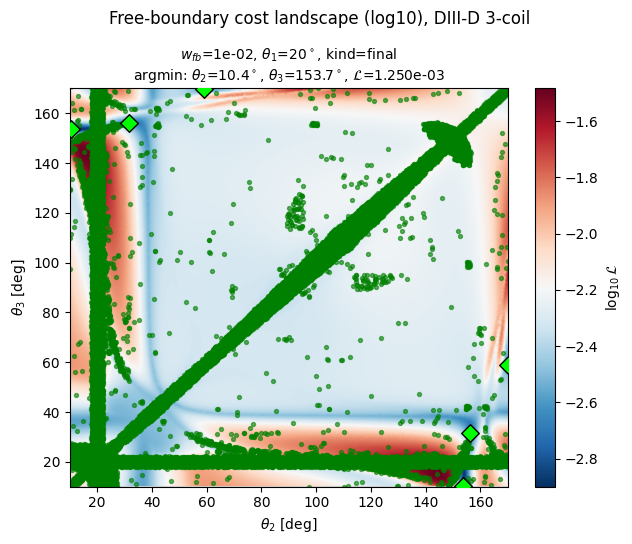

In [24]:
available = [w for w in WEIGHTS if w in data]
nr, nc = grid_shape(len(available))
fig, axes = plt.subplots(nr, nc, figsize=fig_size(nr, nc, h_per=5.5), squeeze=False)
for ax, w in zip(axes.flat, available):
    im = plot_heatmap(ax, data[w], w, log10=True); plt.colorbar(im, ax=ax, label=r'$\log_{10}\mathcal{L}$')
for ax in axes.flat[len(available):]:
    ax.set_visible(False)
fig.suptitle('Free-boundary cost landscape (log10), DIII-D 3-coil', fontsize=12)
fig.tight_layout()
plt.show()

In [25]:
def plot_slice(ax, d, equation, w_key, log10=False, method='linear', show_scatter=False, scatter_tol=0.5):
    s, c = preprocess_cost(d['samples'], d['cost'])
    x = equation['x']
    cq = griddata(s, c, equation['query'], method=method)
    y = np.log10(cq) if log10 else cq
    ax.plot(x, y, lw=1.5, color='C0')
    if show_scatter:
        mask = equation['scatter_mask'](s, scatter_tol)
        sx = equation['scatter_x'](s[mask])
        sy = c[mask]
        if log10:
            sy = np.log10(sy)
        ax.scatter(sx, sy, s=3, alpha=1, color='purple', zorder=0)
    ax.set_xlabel(equation['xlabel'])
    ax.set_ylabel(r'$\log_{10}\mathcal{L}$' if log10 else r'$\mathcal{L}$')
    ax.set_title(rf'$w_{{fb}}$={w_key}, $\theta_1$={THETA1_ANCHOR:.0f}$^\circ$' + '\n' + equation['desc'], fontsize=10)
    ax.grid(True, alpha=0.3)
    return ax

def build_constant_theta2(target, n=512):
    th_lo, th_hi = ANGULAR_BOUNDS
    x = np.linspace(th_lo, th_hi, n)
    query = np.column_stack([np.full(n, target), x])
    return {
        'query': query,
        'x': x,
        'xlabel': r'$\theta_3$ [deg]',
        'desc': rf'$\theta_2$={target:.1f}$^\circ$',
        'scatter_mask': lambda s, tol: np.abs(s[:, 0] - target) < tol,
        'scatter_x': lambda s: s[:, 1],
    }

def build_antidiagonal(total=170.0, n=512):
    th_lo, th_hi = ANGULAR_BOUNDS
    x = np.linspace(th_lo, th_hi, n)
    other = total - x
    mask = (other >= th_lo) & (other <= th_hi)
    x = x[mask]
    query = np.column_stack([x, total - x])
    return {
        'query': query,
        'x': x,
        'xlabel': rf'$\theta_2$ [deg] (with $\theta_3 = {total:.0f} - \theta_2$)',
        'desc': rf'$\theta_2 + \theta_3 = {total:.0f}$',
        'scatter_mask': lambda s, tol: np.abs(s[:, 0] + s[:, 1] - total) < tol,
        'scatter_x': lambda s: s[:, 0],
    }

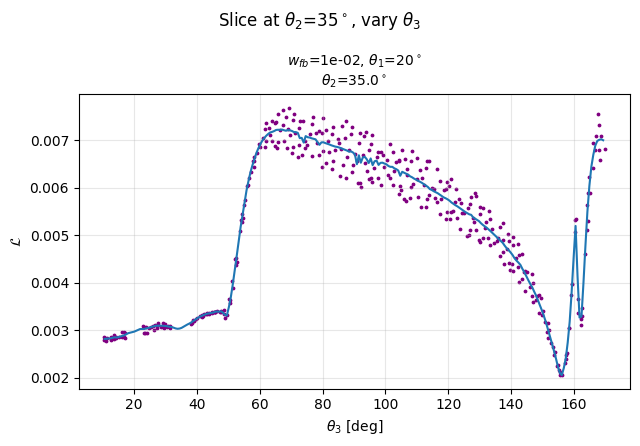

In [26]:
THETA2_CONST = 35
constant_theta2_eq = build_constant_theta2(target=THETA2_CONST, n=256)
available = [w for w in WEIGHTS if w in data]
nr, nc = grid_shape(len(available))
fig, axes = plt.subplots(nr, nc, figsize=fig_size(nr, nc, h_per=4.5), squeeze=False)
for ax, w in zip(axes.flat, available):
    plot_slice(ax, data[w], constant_theta2_eq, w, log10=False, show_scatter=True)
for ax in axes.flat[len(available):]:
    ax.set_visible(False)
fig.suptitle(rf'Slice at $\theta_2$={THETA2_CONST}$^\circ$, vary $\theta_3$', fontsize=12)
fig.tight_layout()
plt.show()

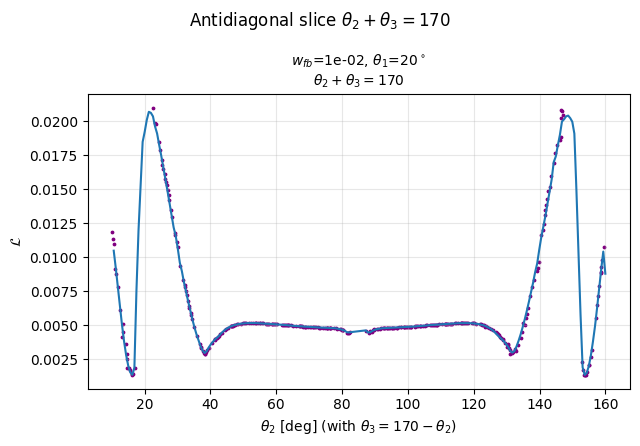

In [27]:
ANTIDIAG_TOTAL = 170.0
antidiagonal_eq = build_antidiagonal(total=ANTIDIAG_TOTAL, n=256)
available = [w for w in WEIGHTS if w in data]
nr, nc = grid_shape(len(available))
fig, axes = plt.subplots(nr, nc, figsize=fig_size(nr, nc, h_per=4.5), squeeze=False)
for ax, w in zip(axes.flat, available):
    plot_slice(ax, data[w], antidiagonal_eq, w, log10=False, show_scatter=True)
for ax in axes.flat[len(available):]:
    ax.set_visible(False)
fig.suptitle(rf'Antidiagonal slice $\theta_2 + \theta_3 = {ANTIDIAG_TOTAL:.0f}$', fontsize=12)
fig.tight_layout()
plt.show()